# 10. Time-Series Anomaly Detection

The previous notebook studied reconstruction error for tabular monitoring. This notebook adds the most important complication in operational monitoring: **time**.

A value that looks extreme at one hour may be ordinary at another hour. A value that is normal by itself may become suspicious when it persists for six hours. A metric that looks bad may be expected during a planned launch, while a subtle deviation during peak traffic may be a serious incident.

Time-series anomaly detection is therefore less about asking whether a number is large and more about asking whether the observed behavior is surprising **given temporal context**.

We will build an hourly checkout reliability monitor using:

1. Seasonal baselines.
2. Robust residual scores.
3. Forecasting residuals with lag and calendar features.
4. Capacity-aware alert queues.
5. Event-level evaluation for incident windows.


## Learning Objectives

By the end of this lecture, you should be able to:

1. Distinguish point, contextual, and collective anomalies in time series.
2. Explain why raw thresholds fail under seasonality and trend.
3. Build a seasonal baseline using hour-of-week profiles.
4. Build a forecasting residual detector using lag, traffic, and calendar features.
5. Calibrate robust anomaly scores with median absolute deviation.
6. Evaluate alerts using both point-level and event-level metrics.
7. Translate temporal anomaly scores into incident response, suppression, monitoring, or model-redesign decisions.


In [1]:
# Section focus: Learning Objectives.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

import sys
import warnings
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.metrics import average_precision_score, precision_recall_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler

repo_root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'notebooks' / '_shared' / 'display.py').exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from notebooks._shared.display import smart_display

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 130
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['legend.fontsize'] = 8
plt.rcParams['legend.title_fontsize'] = 8
pd.set_option('display.max_columns', 100)

RANDOM_SEED = 51010
rng = np.random.default_rng(RANDOM_SEED)

PALETTE = {
    'observed': '#334155',
    'seasonal': '#2563eb',
    'forecast': '#059669',
    'threshold': '#111827',
    'incident': '#dc2626',
    'benign': '#f59e0b',
    'alert': '#7c3aed',
    'normal': '#94a3b8',
}


## 1. What Makes Time-Series Anomaly Detection Different?

For independent tabular observations, we often score each row as if order does not matter. In a time series, the same value can mean different things depending on seasonality, trend, recent history, and business calendar.

Let $y_t$ be the metric observed at time $t$. A generic anomaly score compares the observation to an expected value given temporal information:

$$
s_t = |y_t - E[y_t \; | \; H_t]|.
$$

Here $H_t$ is the information available before or at time $t$.

The key modeling question asks **what belongs in the temporal context?** It may include hour of day, day of week, lagged values, rolling medians, traffic volume, launch calendars, holiday indicators, or correlated service metrics.


## 2. Point, Contextual, and Collective Anomalies

| Type | Meaning | Example in operations |
|---|---|---|
| Point anomaly | One timestamp is individually extreme | A sudden checkout drop for one hour |
| Contextual anomaly | The value is unusual given time or covariates | Normal-looking traffic during a major expected peak |
| Collective anomaly | A sequence is abnormal even if individual points are mild | Six hours of gradual error-rate degradation |
| Benign business shock | Statistical surprise that is not an incident | Marketing campaign increases traffic and orders |

This taxonomy matters for decision science. The response to a checkout outage is incident escalation. The response to a planned promotion is suppression or annotation. The response to a slow degradation may be watchful escalation, not a pager after the first point.


## 3. Robust Residual Scores

Time-series detectors often produce a residual:

$$
e_t = y_t - \hat{y}_t.
$$

A scale-adjusted residual score is then

$$
z_t = \frac{|e_t|}{\sigma_t}.
$$

In production monitoring, robust scale estimates are usually safer than ordinary standard deviations because the calibration period can contain unlabelled anomalies. We will use the median absolute deviation:

$$
MAD(x) = median(|x_i - median(x)|).
$$

For roughly normal residuals, $1.4826 \cdot MAD$ is comparable to a standard deviation. The exact constant matters less than the principle: use a scale estimate that is not dominated by a few incidents.


## 4. Synthetic Case: Hourly Checkout Reliability

Imagine an e-commerce platform monitoring hourly checkout success. The incident team tracks successful checkouts, visits, latency, and error rate.

The metric has strong daily and weekly seasonality. Weekend traffic differs from weekday traffic. Planned marketing campaigns can produce legitimate surges. Real incidents can appear as sharp drops, contextual drops, or multi-hour degradation.

The decision question asks **which hours should be escalated to incident review, which should be suppressed as planned business events, and which should remain on watch?**

The row grain is one hour of checkout operations. The simulated process includes calendar structure, traffic volume, latency, error rate, marketing surges, and several incident types. That makes the problem more realistic than a plain seasonal series because the detector must separate expected traffic variation from operational harm.

The experiment compares residual-based alerting, robust thresholds, and event-level evaluation. A point detector may flag isolated hours, but an incident team usually cares about whether a multi-hour degradation is detected early enough to act. The dataset is built to keep that operational distinction visible.


In [2]:
# Section focus: 4. Synthetic Case: Hourly Checkout Reliability.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def simulate_checkout_series(seed=RANDOM_SEED):
    """Create a simulated checkout series data set for the 10. Time-Series Anomaly Detection case study.
    
    Parameters
    ----------
    seed : object
        Random seed used to make the simulation reproducible.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rng = np.random.default_rng(seed)
    idx = pd.date_range('2026-01-01', periods=24 * 95, freq='h')
    df = pd.DataFrame({'timestamp': idx})
    df['hour'] = df['timestamp'].dt.hour
    df['dow'] = df['timestamp'].dt.dayofweek
    df['hour_of_week'] = df['dow'] * 24 + df['hour']
    df['day_index'] = np.arange(len(df)) / 24

    daily = 1.0 + 0.33 * np.sin(2 * np.pi * (df['hour'] - 14) / 24) + 0.12 * np.sin(4 * np.pi * (df['hour'] - 17) / 24)
    weekly = np.where(df['dow'].isin([5, 6]), 0.82, 1.0) * np.where(df['dow'].eq(0), 1.08, 1.0)
    trend = 1.0 + 0.0018 * df['day_index']
    visits = 9200 * daily * weekly * trend + rng.normal(0, 360, len(df))
    visits = np.clip(visits, 2200, None)

    latency_ms = 235 + 18 * np.sin(2 * np.pi * (df['hour'] - 16) / 24) + rng.normal(0, 12, len(df))
    error_rate = 0.008 + 0.0025 * np.maximum(daily - 1.0, 0) + rng.normal(0, 0.0016, len(df))
    error_rate = np.clip(error_rate, 0.001, 0.04)
    conversion_rate = 0.074 - 0.000075 * np.maximum(latency_ms - 240, 0) - 0.55 * error_rate + rng.normal(0, 0.0025, len(df))
    conversion_rate = np.clip(conversion_rate, 0.035, 0.095)
    checkouts = visits * conversion_rate + rng.normal(0, 38, len(df))
    checkouts = np.clip(checkouts, 20, None)

    df['visits'] = visits
    df['latency_ms'] = latency_ms
    df['error_rate'] = error_rate
    df['successful_checkouts'] = checkouts
    df['event_type'] = 'normal'
    df['is_incident'] = 0
    df['is_benign_event'] = 0

    def apply_window(start, length, event_type, checkout_multiplier=1.0, visits_multiplier=1.0, latency_add=0, error_add=0, incident=True, benign=False):
        """Carry out the apply window step used in the 10. Time-Series Anomaly Detection workflow.
        
        Parameters
        ----------
        start : object
            Starting index, time, or location for the simulated event window.
        length : object
            The length setting that controls the apply window calculation in this notebook.
        event_type : object
            The event type setting that controls the apply window calculation in this notebook.
        checkout_multiplier : object
            The checkout multiplier setting that controls the apply window calculation in this notebook.
        visits_multiplier : object
            The visits multiplier setting that controls the apply window calculation in this notebook.
        latency_add : object
            The latency add setting that controls the apply window calculation in this notebook.
        error_add : object
            The error add setting that controls the apply window calculation in this notebook.
        incident : object
            The incident setting that controls the apply window calculation in this notebook.
        benign : object
            The benign setting that controls the apply window calculation in this notebook.
        
        Returns
        -------
        object
            None. The function updates a plot, display object, or notebook state as its side effect.
        """
        mask = (df['timestamp'] >= pd.Timestamp(start)) & (df['timestamp'] < pd.Timestamp(start) + pd.Timedelta(hours=length))
        df.loc[mask, 'successful_checkouts'] *= checkout_multiplier
        df.loc[mask, 'visits'] *= visits_multiplier
        df.loc[mask, 'latency_ms'] += latency_add
        df.loc[mask, 'error_rate'] = np.clip(df.loc[mask, 'error_rate'] + error_add, 0, 0.25)
        df.loc[mask, 'event_type'] = event_type
        df.loc[mask, 'is_incident'] = int(incident)
        df.loc[mask, 'is_benign_event'] = int(benign)

    apply_window('2026-03-05 13:00', 3, 'payment_gateway_outage', checkout_multiplier=0.42, latency_add=110, error_add=0.065)
    apply_window('2026-03-14 18:00', 7, 'slow_checkout_degradation', checkout_multiplier=0.72, latency_add=65, error_add=0.035)
    apply_window('2026-03-23 10:00', 4, 'contextual_peak_drop', checkout_multiplier=0.70, latency_add=45, error_add=0.018)
    apply_window('2026-03-29 00:00', 5, 'analytics_pipeline_gap', checkout_multiplier=0.55, visits_multiplier=0.92, latency_add=5, error_add=0.002)
    apply_window('2026-03-19 09:00', 10, 'planned_marketing_campaign', checkout_multiplier=1.26, visits_multiplier=1.34, latency_add=22, error_add=0.005, incident=False, benign=True)

    # A single sharp but short point incident.
    apply_window('2026-03-31 16:00', 1, 'one_hour_checkout_spike', checkout_multiplier=1.55, visits_multiplier=1.03, latency_add=75, error_add=0.025)

    return df


df = simulate_checkout_series()
train_end = pd.Timestamp('2026-03-01')
calibration_end = pd.Timestamp('2026-03-08')

df['split'] = np.select(
    [df['timestamp'] < train_end, df['timestamp'] < calibration_end],
    ['train', 'calibration'],
    default='monitoring',
)

summary = df.groupby('split').agg(
    rows=('timestamp', 'size'),
    start=('timestamp', 'min'),
    end=('timestamp', 'max'),
    incident_rate=('is_incident', 'mean'),
    benign_event_rate=('is_benign_event', 'mean'),
).reset_index()

smart_display(summary.style.format({'incident_rate': '{:.1%}', 'benign_event_rate': '{:.1%}'}))
smart_display(df.loc[df['event_type'].ne('normal'), ['event_type', 'timestamp', 'successful_checkouts', 'visits', 'latency_ms', 'error_rate']].groupby('event_type').agg(
    start=('timestamp', 'min'),
    end=('timestamp', 'max'),
    hours=('timestamp', 'size'),
    mean_checkouts=('successful_checkouts', 'mean'),
    mean_latency_ms=('latency_ms', 'mean'),
    mean_error_rate=('error_rate', 'mean'),
).reset_index().style.format({'mean_checkouts': '{:.0f}', 'mean_latency_ms': '{:.0f}', 'mean_error_rate': '{:.2%}'}))


,split,rows,start,end,incident_rate,benign_event_rate
0,calibration,168,2026-03-01 00:00:00,2026-03-07 23:00:00,1.8%,0.0%
1,monitoring,696,2026-03-08 00:00:00,2026-04-05 23:00:00,2.4%,1.4%
2,train,1416,2026-01-01 00:00:00,2026-02-28 23:00:00,0.0%,0.0%


,event_type,start,end,hours,mean_checkouts,mean_latency_ms,mean_error_rate
0,analytics_pipeline_gap,2026-03-29 00:00:00,2026-03-29 04:00:00,5,299,259,1.04%
1,contextual_peak_drop,2026-03-23 10:00:00,2026-03-23 13:00:00,4,434,265,2.59%
2,one_hour_checkout_spike,2026-03-31 16:00:00,2026-03-31 16:00:00,1,1227,307,3.42%
3,payment_gateway_outage,2026-03-05 13:00:00,2026-03-05 15:00:00,3,281,335,7.37%
4,planned_marketing_campaign,2026-03-19 09:00:00,2026-03-19 18:00:00,10,823,245,1.34%
5,slow_checkout_degradation,2026-03-14 18:00:00,2026-03-15 00:00:00,7,549,310,4.37%


The training period is intended to represent ordinary behavior. The calibration period mimics a short recent period used to set thresholds. The monitoring period contains a mixture of real incident windows and one planned marketing campaign.

This is a deliberate teaching setup. We need both incident and non-incident surprises so we can test whether the monitoring workflow distinguishes statistical surprise from operational harm.


## 5. Visual Inspection Before Modeling

Before fitting any detector, inspect the time series. A detector that ignores obvious seasonality will either over-alert every normal peak or miss contextual drops during high-demand periods.


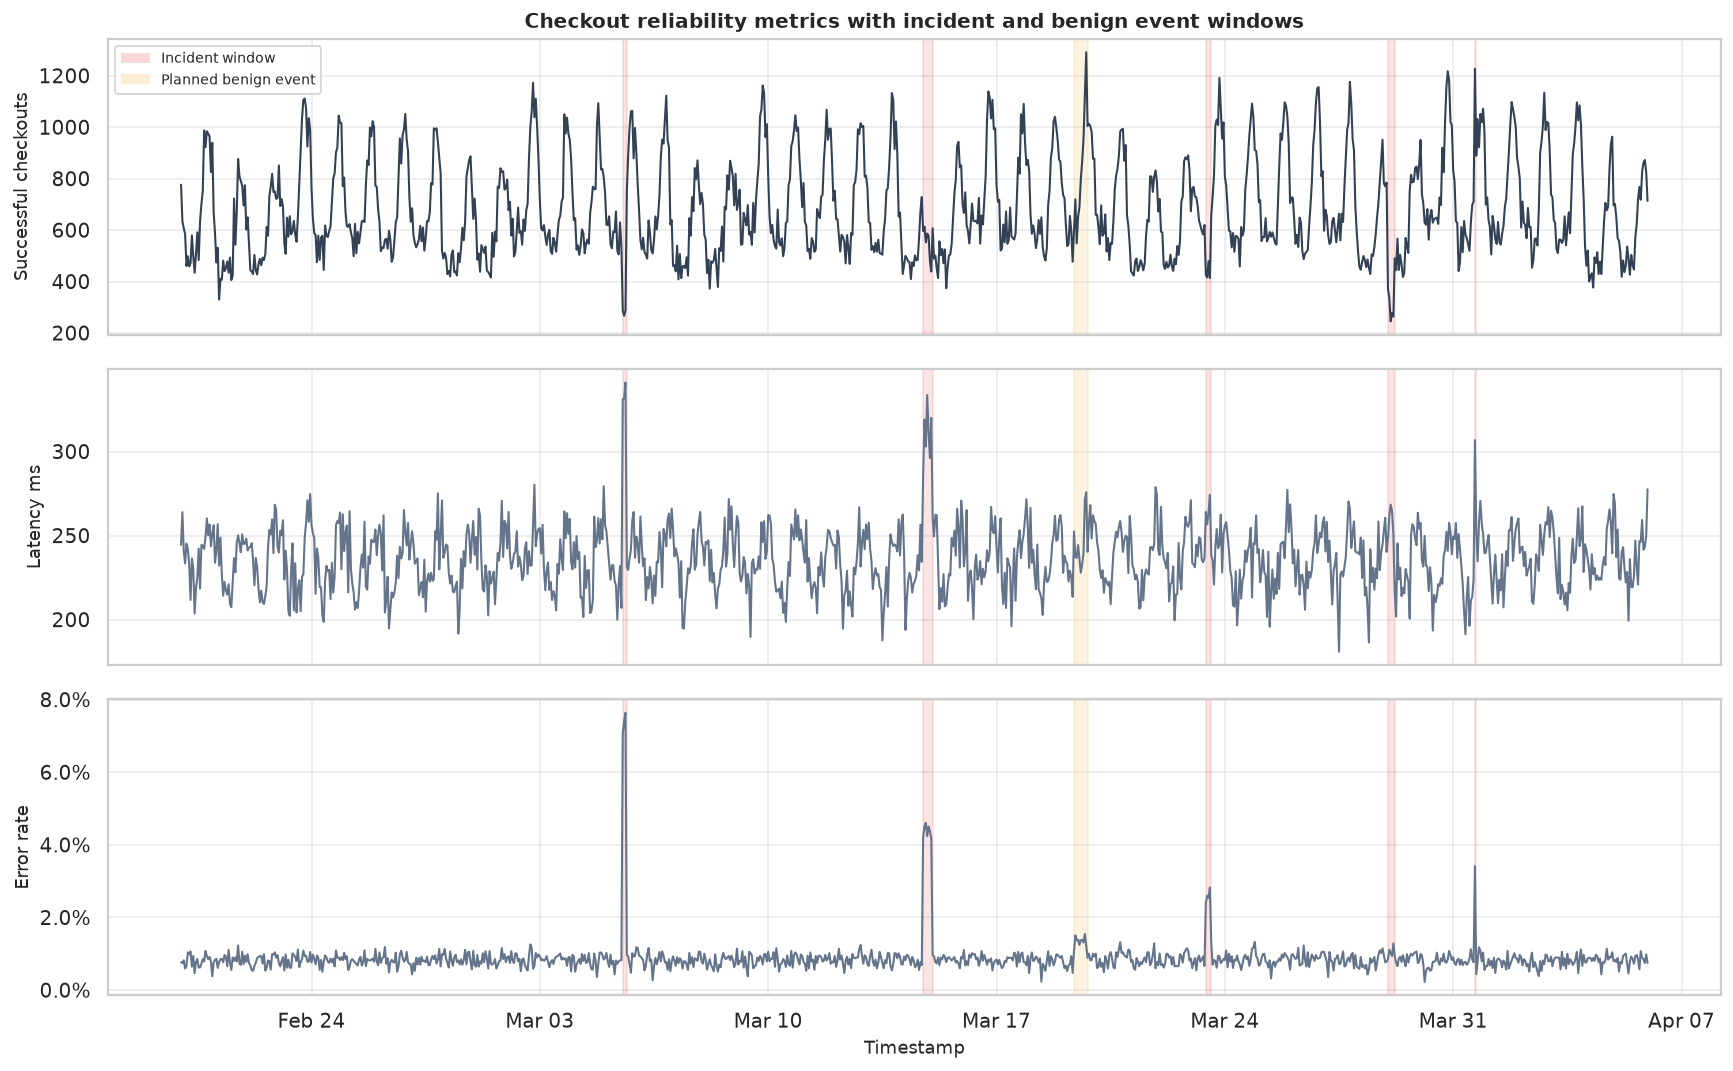

In [3]:
# Section focus: 5. Visual Inspection Before Modeling.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

fig, axes = plt.subplots(3, 1, figsize=(13.5, 8.4), sharex=True)
monitor_start = pd.Timestamp('2026-02-20')
plot_df = df[df['timestamp'] >= monitor_start].copy()
incident_windows = plot_df[plot_df['is_incident'].eq(1)]
benign_windows = plot_df[plot_df['is_benign_event'].eq(1)]

for ax, col, ylabel, color in [
    (axes[0], 'successful_checkouts', 'Successful checkouts', PALETTE['observed']),
    (axes[1], 'latency_ms', 'Latency ms', '#64748b'),
    (axes[2], 'error_rate', 'Error rate', '#64748b'),
]:
    ax.plot(plot_df['timestamp'], plot_df[col], color=color, linewidth=1.15)
    for event_type, event_df in plot_df[plot_df['event_type'].ne('normal')].groupby('event_type'):
        start, end = event_df['timestamp'].min(), event_df['timestamp'].max()
        fill = PALETTE['benign'] if event_df['is_benign_event'].max() else PALETTE['incident']
        ax.axvspan(start, end + pd.Timedelta(hours=1), color=fill, alpha=0.12)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.35)
axes[0].set_title('Checkout reliability metrics with incident and benign event windows')
axes[2].set_xlabel('Timestamp')
axes[2].yaxis.set_major_formatter(lambda x, pos: f'{x:.1%}')
axes[2].xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
legend_handles = [
    Patch(facecolor=PALETTE['incident'], alpha=0.18, label='Incident window'),
    Patch(facecolor=PALETTE['benign'], alpha=0.18, label='Planned benign event'),
]
axes[0].legend(handles=legend_handles, loc='upper left')
plt.tight_layout()
plt.show()


The same chart contains several anomaly types. The outage is visually obvious. The contextual drop is harder because the absolute checkout volume may not look catastrophic, but it occurs during a time when the system should be strong. The slow degradation becomes meaningful as a sequence.

This is why a time-series detector should be evaluated against windows and context, alongside isolated points.


## 6. Seasonal Baseline Detector

A simple and surprisingly useful baseline is an hour-of-week profile. Let $h(t)$ be the hour-of-week for timestamp $t$. We estimate the expected checkout count by the historical median for that hour:

$$
\hat{y}_t = median(y_i: h(i) = h(t)).
$$

Then we score the absolute residual using a robust hour-specific scale:

$$
score_t = \frac{|y_t - \hat{y}_t|}{1.4826 \cdot MAD_h + c}.
$$

The small constant $c$ prevents division by a very small scale estimate.


In [4]:
# Section focus: 6. Seasonal Baseline Detector.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

train_df = df[df['split'].eq('train')].copy()
calibration_df = df[df['split'].eq('calibration')].copy()
monitor_df = df[df['split'].eq('monitoring')].copy()


def mad(values):
    """Carry out the mad step used in the 10. Time-Series Anomaly Detection workflow.
    
    Parameters
    ----------
    values : object
        The values setting that controls the mad calculation in this notebook.
    
    Returns
    -------
    object
        Intermediate result produced by the mad calculation and reused by later cells.
    """
    values = np.asarray(values, dtype=float)
    med = np.median(values)
    return np.median(np.abs(values - med))

seasonal_profile = train_df.groupby('hour_of_week')['successful_checkouts'].agg(
    seasonal_median='median',
    seasonal_mad=mad,
).reset_index()
seasonal_profile['seasonal_scale'] = 1.4826 * seasonal_profile['seasonal_mad'].clip(lower=8)

df = df.merge(seasonal_profile[['hour_of_week', 'seasonal_median', 'seasonal_scale']], on='hour_of_week', how='left')
df['seasonal_residual'] = df['successful_checkouts'] - df['seasonal_median']
df['seasonal_score'] = df['seasonal_residual'].abs() / df['seasonal_scale']

calibration_scores = df.loc[df['split'].eq('calibration'), 'seasonal_score']
seasonal_threshold = calibration_scores.quantile(0.995)
df['seasonal_boundary_alert'] = df['seasonal_score'] >= seasonal_threshold

seasonal_setup = pd.DataFrame([
    {
        'detector': 'Hour-of-week seasonal residual',
        'calibration_quantile': '99.5th percentile',
        'threshold': seasonal_threshold,
        'calibration_alert_rate': df.loc[df['split'].eq('calibration'), 'seasonal_boundary_alert'].mean(),
        'monitoring_alert_rate': df.loc[df['split'].eq('monitoring'), 'seasonal_boundary_alert'].mean(),
    }
])
smart_display(seasonal_setup.style.format({'threshold': '{:.2f}', 'calibration_alert_rate': '{:.1%}', 'monitoring_alert_rate': '{:.1%}'}))


,detector,calibration_quantile,threshold,calibration_alert_rate,monitoring_alert_rate
0,Hour-of-week seasonal residual,99.5th percentile,9.69,0.6%,0.6%


This detector is transparent and fast. It gives every hour a context-specific baseline. Monday 10 AM is compared with previous Monday 10 AM observations, not with midnight observations.

The weakness is that this baseline only knows historical seasonality. It does not use visits, latency, error rate, or recent lagged behavior. It may over-alert planned campaigns and under-explain incidents where the raw checkout count is partly explained by traffic changes.


## 7. Forecasting Residual Detector

A forecasting detector estimates the next value from temporal and operational features. We use a ridge regression baseline rather than a deep model because the goal is interpretability and stable rendering.

The forecast uses:

- Calendar features: hour and day cyclic encodings.
- Lag features: previous hour, previous day, previous week.
- Operational covariates: visits, latency, and error rate.

The residual score remains the same conceptual object: observed minus expected, scaled robustly.


In [5]:
# Section focus: 7. Forecasting Residual Detector.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def add_forecast_features(input_df):
    """Carry out the add forecast features step used in the 10. Time-Series Anomaly Detection workflow.
    
    Parameters
    ----------
    input_df : object
        Tabular data object used as the input or output of this workflow step.
    
    Returns
    -------
    object
        Tabular or matrix-style object produced by the add forecast features workflow for later analysis.
    """
    out = input_df.copy()
    out['hour_sin'] = np.sin(2 * np.pi * out['hour'] / 24)
    out['hour_cos'] = np.cos(2 * np.pi * out['hour'] / 24)
    out['dow_sin'] = np.sin(2 * np.pi * out['dow'] / 7)
    out['dow_cos'] = np.cos(2 * np.pi * out['dow'] / 7)
    for lag in [1, 24, 168]:
        out[f'checkout_lag_{lag}'] = out['successful_checkouts'].shift(lag)
        out[f'visits_lag_{lag}'] = out['visits'].shift(lag)
    out['rolling_24h_median'] = out['successful_checkouts'].shift(1).rolling(24, min_periods=12).median()
    out['rolling_168h_median'] = out['successful_checkouts'].shift(1).rolling(168, min_periods=48).median()
    return out

feature_df = add_forecast_features(df)
FORECAST_FEATURES = [
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
    'visits', 'latency_ms', 'error_rate',
    'checkout_lag_1', 'checkout_lag_24', 'checkout_lag_168',
    'visits_lag_1', 'visits_lag_24', 'visits_lag_168',
    'rolling_24h_median', 'rolling_168h_median',
]
model_df = feature_df.dropna(subset=FORECAST_FEATURES + ['successful_checkouts']).copy()
train_model = model_df[model_df['split'].eq('train')].copy()
cal_model = model_df[model_df['split'].eq('calibration')].copy()
monitor_model = model_df[model_df['split'].eq('monitoring')].copy()

x_scaler = StandardScaler()
y_scaler = StandardScaler()
X_train = x_scaler.fit_transform(train_model[FORECAST_FEATURES])
y_train = train_model['successful_checkouts'].to_numpy()

forecast_model = Ridge(alpha=4.0)
forecast_model.fit(X_train, y_train)

model_df['forecast_expected'] = forecast_model.predict(x_scaler.transform(model_df[FORECAST_FEATURES]))
model_df['forecast_residual'] = model_df['successful_checkouts'] - model_df['forecast_expected']
resid_scale = 1.4826 * mad(model_df.loc[model_df['split'].eq('calibration'), 'forecast_residual'])
resid_scale = max(resid_scale, 12)
model_df['forecast_score'] = model_df['forecast_residual'].abs() / resid_scale
forecast_threshold = model_df.loc[model_df['split'].eq('calibration'), 'forecast_score'].quantile(0.995)
model_df['forecast_boundary_alert'] = model_df['forecast_score'] >= forecast_threshold

# Add forecast columns back to df for unified analysis.
forecast_cols = ['timestamp', 'forecast_expected', 'forecast_residual', 'forecast_score', 'forecast_boundary_alert']
df = df.merge(model_df[forecast_cols], on='timestamp', how='left')

forecast_setup = pd.DataFrame([
    {
        'detector': 'Ridge one-step forecast residual',
        'number_of_features': len(FORECAST_FEATURES),
        'residual_scale': resid_scale,
        'threshold': forecast_threshold,
        'calibration_alert_rate': df.loc[df['split'].eq('calibration'), 'forecast_boundary_alert'].mean(),
        'monitoring_alert_rate': df.loc[df['split'].eq('monitoring'), 'forecast_boundary_alert'].mean(),
    }
])
smart_display(forecast_setup.style.format({
    'residual_scale': '{:.2f}',
    'threshold': '{:.2f}',
    'calibration_alert_rate': '{:.1%}',
    'monitoring_alert_rate': '{:.1%}',
}))


,detector,number_of_features,residual_scale,threshold,calibration_alert_rate,monitoring_alert_rate
0,Ridge one-step forecast residual,15,49.78,2.69,0.6%,1.4%


The forecasting detector is more contextual than the seasonal baseline. It knows, for example, whether visits were unusually high and whether latency or error rate deteriorated.

That extra context can reduce false alerts for benign demand surges. It can also create a governance risk: if a covariate is itself affected by the incident, the model may explain away part of the anomaly. In monitoring, covariate choice is not neutral.


## 8. Compare Expected Values and Residual Alerts

We now visualize observed checkouts against the seasonal baseline and the forecasting baseline. We also mark threshold-based alerts.


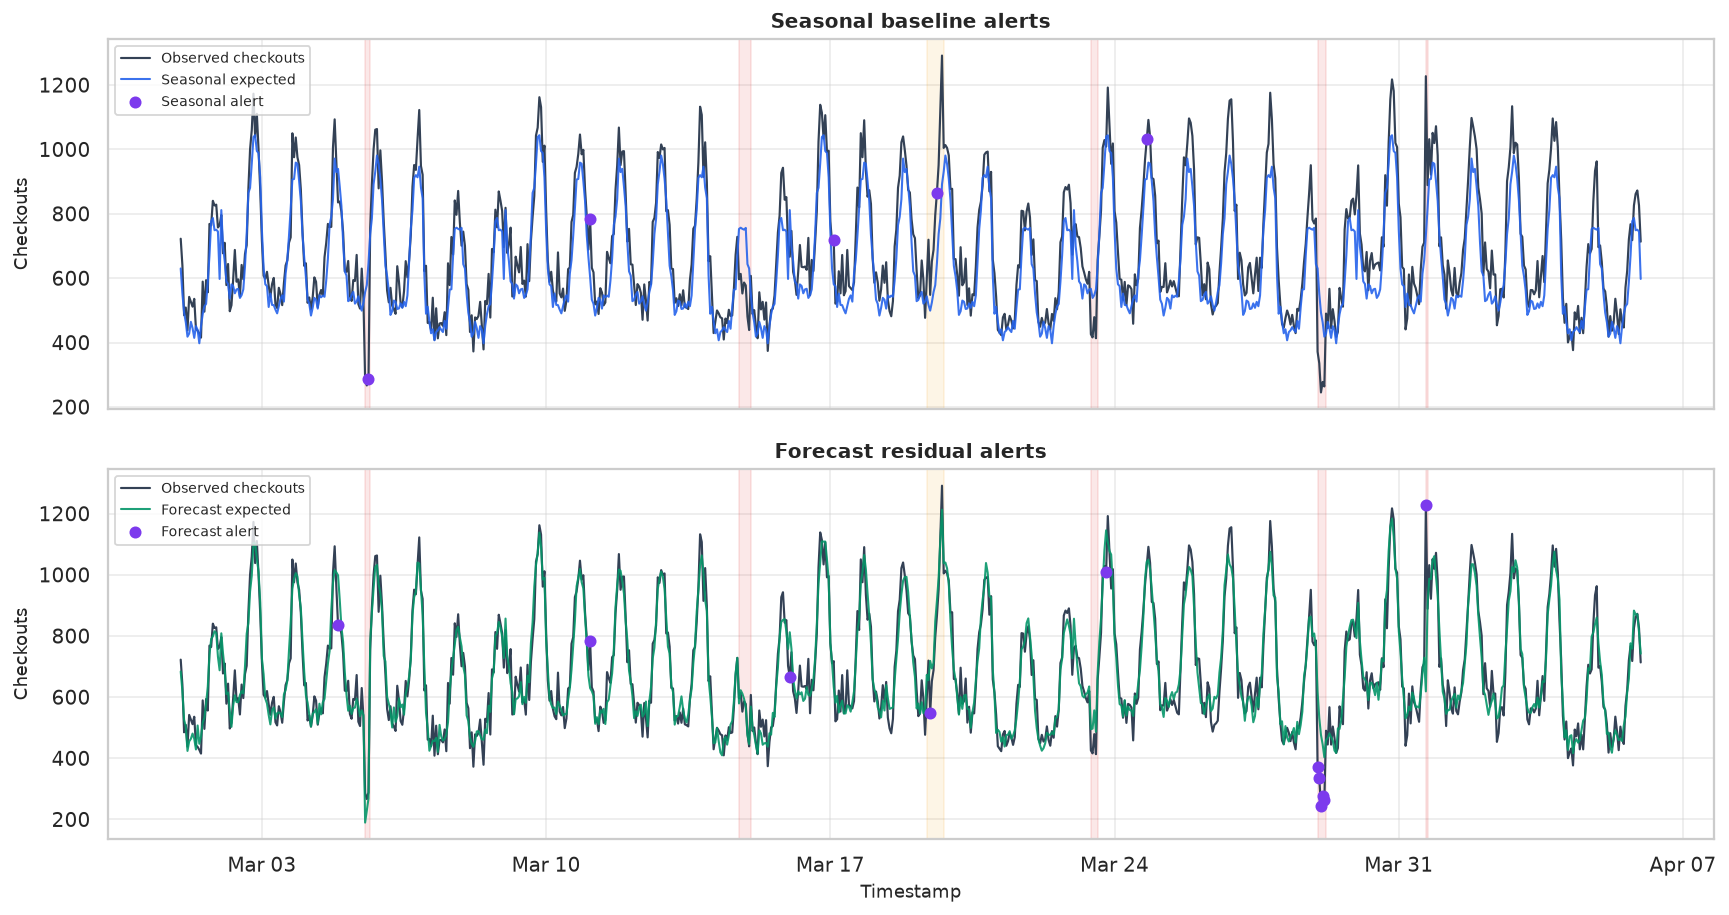

In [6]:
# Section focus: 8. Compare Expected Values and Residual Alerts.
# The code below keeps the calculation explicit so each intermediate step can be inspected.

plot_df = df[df['timestamp'] >= pd.Timestamp('2026-03-01')].copy()
fig, axes = plt.subplots(2, 1, figsize=(13.5, 7.2), sharex=True)

axes[0].plot(plot_df['timestamp'], plot_df['successful_checkouts'], color=PALETTE['observed'], linewidth=1.2, label='Observed checkouts')
axes[0].plot(plot_df['timestamp'], plot_df['seasonal_median'], color=PALETTE['seasonal'], linewidth=1.15, alpha=0.9, label='Seasonal expected')
seasonal_alerts = plot_df[plot_df['seasonal_boundary_alert'].fillna(False)]
axes[0].scatter(seasonal_alerts['timestamp'], seasonal_alerts['successful_checkouts'], color=PALETTE['alert'], s=32, marker='o', label='Seasonal alert', zorder=5)

axes[1].plot(plot_df['timestamp'], plot_df['successful_checkouts'], color=PALETTE['observed'], linewidth=1.2, label='Observed checkouts')
axes[1].plot(plot_df['timestamp'], plot_df['forecast_expected'], color=PALETTE['forecast'], linewidth=1.15, alpha=0.9, label='Forecast expected')
forecast_alerts = plot_df[plot_df['forecast_boundary_alert'].fillna(False)]
axes[1].scatter(forecast_alerts['timestamp'], forecast_alerts['successful_checkouts'], color=PALETTE['alert'], s=32, marker='o', label='Forecast alert', zorder=5)

for ax in axes:
    for event_type, event_df in plot_df[plot_df['event_type'].ne('normal')].groupby('event_type'):
        fill = PALETTE['benign'] if event_df['is_benign_event'].max() else PALETTE['incident']
        ax.axvspan(event_df['timestamp'].min(), event_df['timestamp'].max() + pd.Timedelta(hours=1), color=fill, alpha=0.10)
    ax.set_ylabel('Checkouts')
    ax.grid(True, alpha=0.35)
    ax.legend(loc='upper left')
axes[0].set_title('Seasonal baseline alerts')
axes[1].set_title('Forecast residual alerts')
axes[1].set_xlabel('Timestamp')
axes[1].xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.tight_layout()
plt.show()


The visual comparison is useful because it shows what each detector expected. An alert is a disagreement between observation and baseline.

If a detector alerts during every planned marketing window, the model may still be statistically correct but operationally noisy. If a detector misses slow degradation because each point is only mildly surprising, the alert policy may need sequence logic.


## 9. Point-Level Metrics and Review Queues

In streaming monitoring, a threshold may generate too many alerts. A fixed review queue can be more realistic: for example, review only the top 3% highest-scoring hours each week.

We compare boundary alerts with top-score review alerts.


,model,rule,alert_rate,precision,recall,false_alert_rate_on_non_incidents,average_precision,roc_auc
0,Seasonal residual,Calibration boundary,0.6%,0.0%,0.0%,0.6%,0.126,0.857
1,Seasonal residual,Top 3% review,3.0%,14.3%,17.6%,2.7%,0.126,0.857
2,Forecast residual,Calibration boundary,1.4%,60.0%,35.3%,0.6%,0.362,0.672
3,Forecast residual,Top 3% review,3.0%,28.6%,35.3%,2.2%,0.362,0.672
4,Combined rank score,Top 3% review,3.0%,19.0%,23.5%,2.5%,0.249,0.793


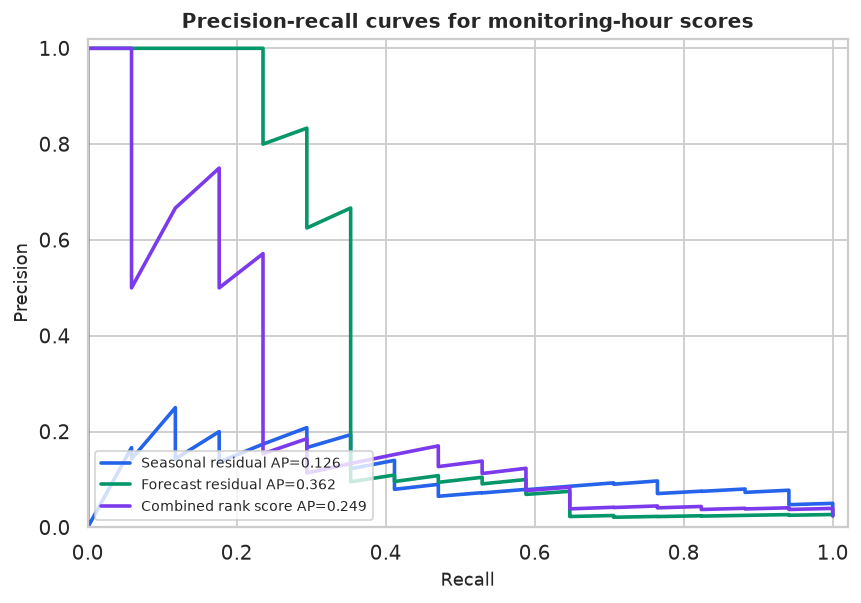

In [7]:
# Section focus: 9. Point-Level Metrics and Review Queues.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

monitor_eval = df[df['split'].eq('monitoring')].dropna(subset=['forecast_score']).copy()
review_fraction = 0.03
seasonal_review_cutoff = monitor_eval['seasonal_score'].quantile(1 - review_fraction)
forecast_review_cutoff = monitor_eval['forecast_score'].quantile(1 - review_fraction)
monitor_eval['seasonal_review_alert'] = monitor_eval['seasonal_score'] >= seasonal_review_cutoff
monitor_eval['forecast_review_alert'] = monitor_eval['forecast_score'] >= forecast_review_cutoff
monitor_eval['combined_score'] = 0.45 * monitor_eval['seasonal_score'].rank(pct=True) + 0.55 * monitor_eval['forecast_score'].rank(pct=True)
combined_review_cutoff = monitor_eval['combined_score'].quantile(1 - review_fraction)
monitor_eval['combined_review_alert'] = monitor_eval['combined_score'] >= combined_review_cutoff

def point_metrics(score_col, alert_col, model_name, rule_name):
    """Carry out the point metrics step used in the 10. Time-Series Anomaly Detection workflow.
    
    Parameters
    ----------
    score_col : object
        Column name containing model scores, risks, priorities, or anomaly scores.
    alert_col : object
        Column name indicating whether an alert was fired by the detector.
    model_name : object
        Model object fitted, evaluated, or compared in this workflow.
    rule_name : object
        The rule name setting that controls the point metrics calculation in this notebook.
    
    Returns
    -------
    object
        Dictionary or table of metrics used to compare model behavior.
    """
    y = monitor_eval['is_incident'].to_numpy().astype(int)
    score = monitor_eval[score_col].to_numpy()
    alert = monitor_eval[alert_col].to_numpy().astype(bool)
    tp = ((alert == 1) & (y == 1)).sum()
    fp = ((alert == 1) & (y == 0)).sum()
    fn = ((alert == 0) & (y == 1)).sum()
    tn = ((alert == 0) & (y == 0)).sum()
    precision = tp / (tp + fp) if (tp + fp) else np.nan
    recall = tp / (tp + fn) if (tp + fn) else np.nan
    false_alert_rate = fp / (fp + tn) if (fp + tn) else np.nan
    return {
        'model': model_name,
        'rule': rule_name,
        'alert_rate': alert.mean(),
        'precision': precision,
        'recall': recall,
        'false_alert_rate_on_non_incidents': false_alert_rate,
        'average_precision': average_precision_score(y, score),
        'roc_auc': roc_auc_score(y, score),
    }

metrics_table = pd.DataFrame([
    point_metrics('seasonal_score', 'seasonal_boundary_alert', 'Seasonal residual', 'Calibration boundary'),
    point_metrics('seasonal_score', 'seasonal_review_alert', 'Seasonal residual', 'Top 3% review'),
    point_metrics('forecast_score', 'forecast_boundary_alert', 'Forecast residual', 'Calibration boundary'),
    point_metrics('forecast_score', 'forecast_review_alert', 'Forecast residual', 'Top 3% review'),
    point_metrics('combined_score', 'combined_review_alert', 'Combined rank score', 'Top 3% review'),
])

smart_display(metrics_table.style.format({
    'alert_rate': '{:.1%}',
    'precision': '{:.1%}',
    'recall': '{:.1%}',
    'false_alert_rate_on_non_incidents': '{:.1%}',
    'average_precision': '{:.3f}',
    'roc_auc': '{:.3f}',
}))

fig, ax = plt.subplots(figsize=(6.8, 4.8))
y = monitor_eval['is_incident'].to_numpy().astype(int)
for score_col, label, color in [
    ('seasonal_score', 'Seasonal residual', PALETTE['seasonal']),
    ('forecast_score', 'Forecast residual', PALETTE['forecast']),
    ('combined_score', 'Combined rank score', PALETTE['alert']),
]:
    precision, recall, _ = precision_recall_curve(y, monitor_eval[score_col])
    ap = average_precision_score(y, monitor_eval[score_col])
    ax.plot(recall, precision, linewidth=2.0, color=color, label=f'{label} AP={ap:.3f}')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_xlim(0, 1.02)
ax.set_ylim(0, 1.02)
ax.set_title('Precision-recall curves for monitoring-hour scores')
ax.legend(loc='lower left')
plt.tight_layout()
plt.show()


Point-level metrics are helpful but incomplete. If an outage lasts seven hours, alerting on five of those hours is different from alerting once at the beginning. In incident response, early detection inside a window may be more valuable than repeated alerts after the issue is already known.

This is why time-series anomaly evaluation often needs event-aware metrics, alongside point classification metrics.


## 10. Event-Level Recall and First-Alert Delay

For each incident window, we ask whether a detector produced at least one alert inside the event. We also compute the delay between the event start and the first alert.

This reflects how incident teams think: did the monitoring system catch the incident, and how long did it take?


,detector,event_type,event_hours,detected,first_alert_delay_hours,alerts_inside_event
0,Seasonal top 3%,analytics_pipeline_gap,5,True,0.0,2
1,Seasonal top 3%,contextual_peak_drop,4,False,nan,0
2,Seasonal top 3%,one_hour_checkout_spike,1,True,0.0,1
3,Seasonal top 3%,slow_checkout_degradation,7,False,nan,0
4,Forecast top 3%,analytics_pipeline_gap,5,True,0.0,5
5,Forecast top 3%,contextual_peak_drop,4,False,nan,0
6,Forecast top 3%,one_hour_checkout_spike,1,True,0.0,1
7,Forecast top 3%,slow_checkout_degradation,7,False,nan,0
8,Combined top 3%,analytics_pipeline_gap,5,True,0.0,3
9,Combined top 3%,contextual_peak_drop,4,False,nan,0


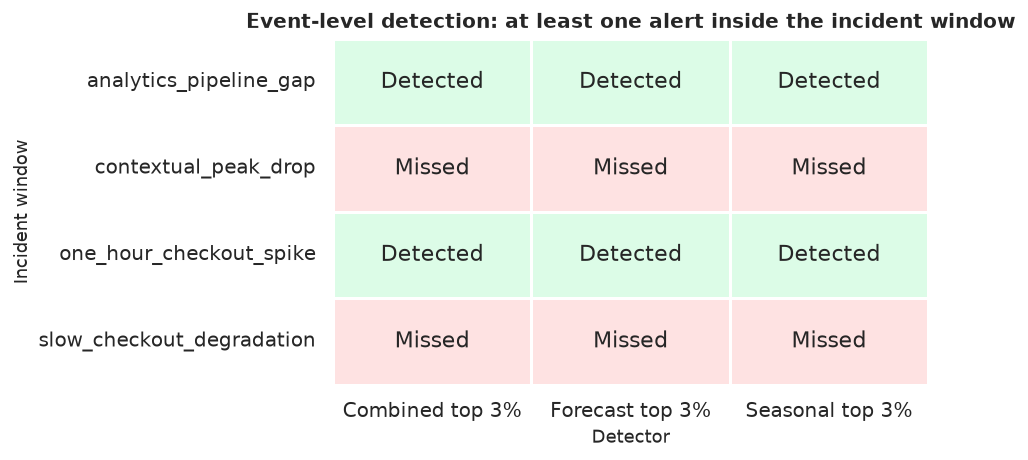

In [8]:
# Section focus: 10. Event-Level Recall and First-Alert Delay.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

event_windows = monitor_eval[monitor_eval['is_incident'].eq(1)].groupby('event_type').agg(
    start=('timestamp', 'min'),
    end=('timestamp', 'max'),
    hours=('timestamp', 'size'),
).reset_index()

def event_detection_summary(alert_col, label):
    """Carry out the event detection summary step used in the 10. Time-Series Anomaly Detection workflow.
    
    Parameters
    ----------
    alert_col : object
        Column name indicating whether an alert was fired by the detector.
    label : object
        Human-readable label used to name a model, scenario, metric, or plotted series.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rows = []
    for _, event in event_windows.iterrows():
        in_window = monitor_eval[(monitor_eval['timestamp'] >= event['start']) & (monitor_eval['timestamp'] <= event['end'])]
        alert_times = in_window.loc[in_window[alert_col].fillna(False), 'timestamp']
        detected = len(alert_times) > 0
        delay = (alert_times.min() - event['start']).total_seconds() / 3600 if detected else np.nan
        rows.append({
            'detector': label,
            'event_type': event['event_type'],
            'event_hours': event['hours'],
            'detected': detected,
            'first_alert_delay_hours': delay,
            'alerts_inside_event': int(in_window[alert_col].fillna(False).sum()),
        })
    return pd.DataFrame(rows)

event_table = pd.concat([
    event_detection_summary('seasonal_review_alert', 'Seasonal top 3%'),
    event_detection_summary('forecast_review_alert', 'Forecast top 3%'),
    event_detection_summary('combined_review_alert', 'Combined top 3%'),
], ignore_index=True)

smart_display(event_table.style.format({'first_alert_delay_hours': '{:.1f}'}))

heat = event_table.pivot(index='event_type', columns='detector', values='detected').astype(float)
fig, ax = plt.subplots(figsize=(7.4, 3.7))
sns.heatmap(heat, annot=heat.replace({1.0: 'Detected', 0.0: 'Missed'}), fmt='', cmap=sns.color_palette(['#fee2e2', '#dcfce7'], as_cmap=True), cbar=False, linewidths=0.8, linecolor='white', ax=ax)
ax.set_xlabel('Detector')
ax.set_ylabel('Incident window')
ax.set_title('Event-level detection: at least one alert inside the incident window')
plt.tight_layout()
plt.show()


Event-level summaries prevent us from over-interpreting point metrics. A detector may have moderate point recall but still catch every incident window quickly. Another detector may fire many redundant alerts inside one easy incident while missing a subtle degradation.

For operational analytics, the event table is often the most persuasive evaluation artifact.


## 11. Benign Event Suppression and Alert Triage

A statistically surprising point is not always a harmful point. The planned marketing campaign increases both visits and checkouts, and may create residual alerts. If the monitoring system pages the incident team for every planned campaign, trust erodes quickly.

We compare how many alerts fall into incident windows, benign event windows, and ordinary monitoring periods.


,detector,total_alert_hours,incident_alert_hours,benign_campaign_alert_hours,ordinary_false_alert_hours,share_alerts_in_incidents
0,Seasonal top 3%,21,3,2,16,14.3%
1,Forecast top 3%,21,6,1,14,28.6%
2,Combined top 3%,21,4,1,16,19.0%


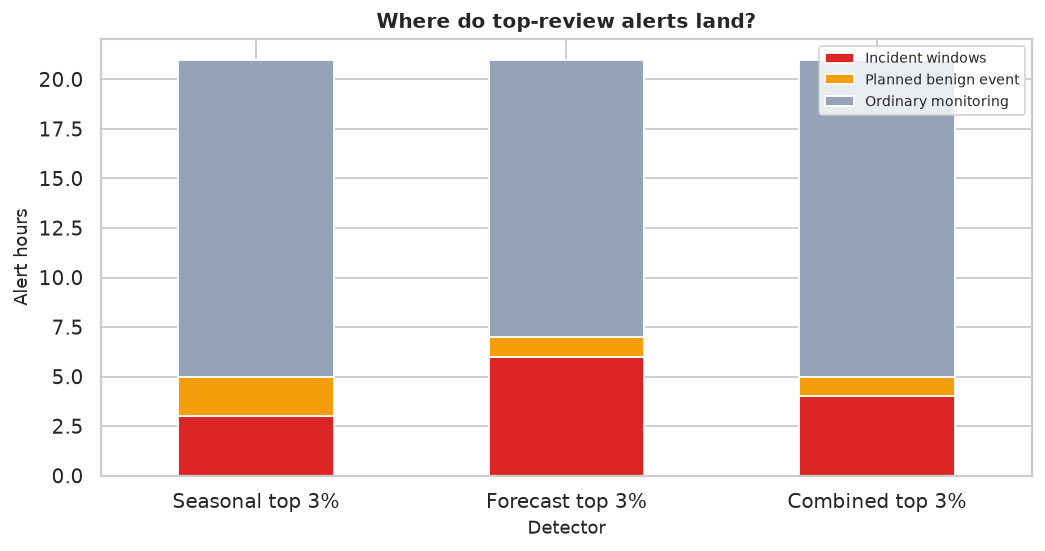

In [9]:
# Section focus: 11. Benign Event Suppression and Alert Triage.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

alert_policy_table = []
for alert_col, label in [
    ('seasonal_review_alert', 'Seasonal top 3%'),
    ('forecast_review_alert', 'Forecast top 3%'),
    ('combined_review_alert', 'Combined top 3%'),
]:
    alerted = monitor_eval[monitor_eval[alert_col].fillna(False)].copy()
    alert_policy_table.append({
        'detector': label,
        'total_alert_hours': len(alerted),
        'incident_alert_hours': int(alerted['is_incident'].sum()),
        'benign_campaign_alert_hours': int(alerted['is_benign_event'].sum()),
        'ordinary_false_alert_hours': int(((alerted['is_incident'] == 0) & (alerted['is_benign_event'] == 0)).sum()),
        'share_alerts_in_incidents': alerted['is_incident'].mean() if len(alerted) else np.nan,
    })
alert_policy_table = pd.DataFrame(alert_policy_table)
smart_display(alert_policy_table.style.format({'share_alerts_in_incidents': '{:.1%}'}))

plot_policy = alert_policy_table.set_index('detector')[['incident_alert_hours', 'benign_campaign_alert_hours', 'ordinary_false_alert_hours']]
fig, ax = plt.subplots(figsize=(8.2, 4.4))
plot_policy.plot(kind='bar', stacked=True, ax=ax, color=[PALETTE['incident'], PALETTE['benign'], PALETTE['normal']])
ax.set_ylabel('Alert hours')
ax.set_xlabel('Detector')
ax.set_title('Where do top-review alerts land?')
ax.legend(['Incident windows', 'Planned benign event', 'Ordinary monitoring'], loc='upper right')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


This table connects model quality to operating cost. A detector that spends scarce review slots on known benign events needs annotation, suppression rules, or a calendar-aware model.

A mature monitoring workflow separates:

1. **Pager alerts:** likely incidents needing immediate action.
2. **Suppressed known events:** planned campaigns, deployments, maintenance windows.
3. **Watchlist alerts:** weak signals that may matter if they persist or recur.


## 12. Why Sequence Logic Matters

A top-score detector can catch sharp events, but slow degradation may need persistence logic. A simple rule is: escalate when at least $m$ of the last $w$ hours exceed a watch threshold.

For example, use a lower forecast score threshold for watch status, then escalate only if the watch status persists. Define the recent watch count as

$$
C_t = \sum_{i=t-w+1}^{t} I(score_i > c).
$$

The escalation rule is simple: alert when $C_t \ge m$.

This turns noisy point scores into incident-level logic.


,model,rule,alert_rate,precision,recall,false_alert_rate_on_non_incidents,average_precision,roc_auc
0,Forecast residual,Persistent watch: 2 of 4 hours,6.2%,9.3%,23.5%,5.7%,0.362,0.672


,detector,event_type,event_hours,detected,first_alert_delay_hours,alerts_inside_event
0,Persistent forecast watch,analytics_pipeline_gap,5,True,1.0,4
1,Persistent forecast watch,contextual_peak_drop,4,False,nan,0
2,Persistent forecast watch,one_hour_checkout_spike,1,False,nan,0
3,Persistent forecast watch,slow_checkout_degradation,7,False,nan,0


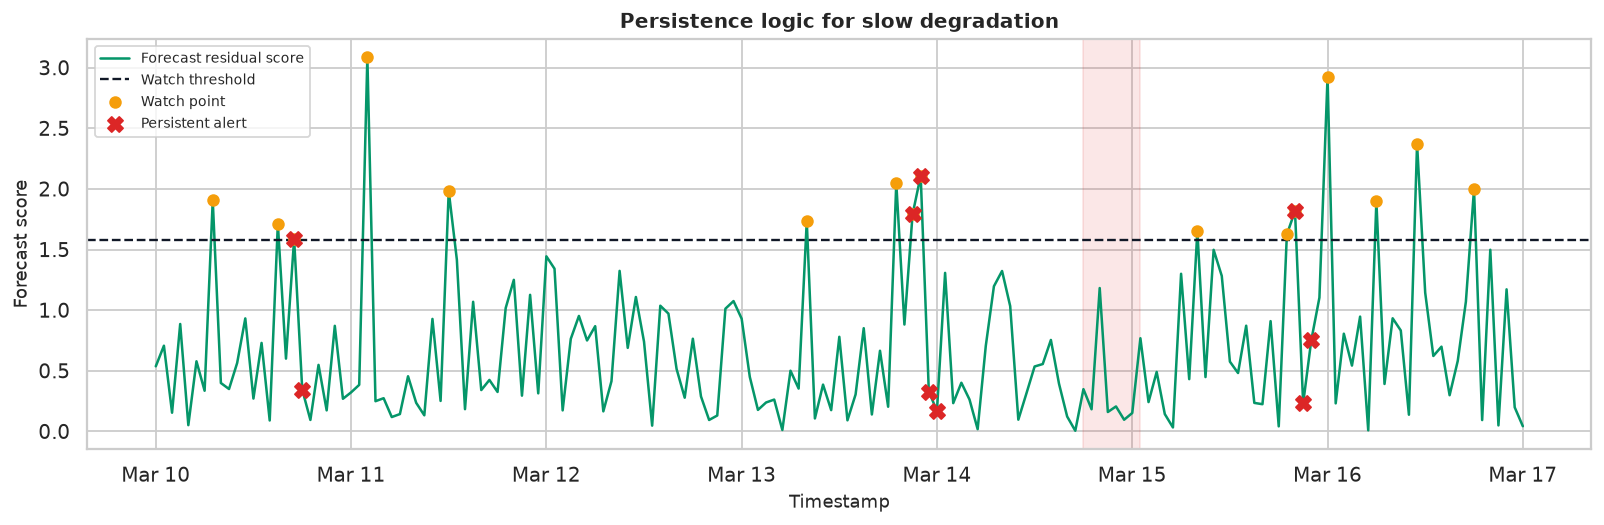

In [10]:
# Section focus: 12. Why Sequence Logic Matters.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

monitor_eval = monitor_eval.sort_values('timestamp').copy()
watch_threshold = monitor_eval['forecast_score'].quantile(0.90)
monitor_eval['forecast_watch'] = monitor_eval['forecast_score'] >= watch_threshold
monitor_eval['persistent_forecast_alert'] = monitor_eval['forecast_watch'].rolling(4, min_periods=4).sum().ge(2)

persistent_metrics = point_metrics('forecast_score', 'persistent_forecast_alert', 'Forecast residual', 'Persistent watch: 2 of 4 hours')
smart_display(pd.DataFrame([persistent_metrics]).style.format({
    'alert_rate': '{:.1%}',
    'precision': '{:.1%}',
    'recall': '{:.1%}',
    'false_alert_rate_on_non_incidents': '{:.1%}',
    'average_precision': '{:.3f}',
    'roc_auc': '{:.3f}',
}))

persistent_event = event_detection_summary('persistent_forecast_alert', 'Persistent forecast watch')
smart_display(persistent_event.style.format({'first_alert_delay_hours': '{:.1f}'}))

plot_df = monitor_eval[(monitor_eval['timestamp'] >= pd.Timestamp('2026-03-10')) & (monitor_eval['timestamp'] <= pd.Timestamp('2026-03-17'))]
fig, ax = plt.subplots(figsize=(12.5, 4.2))
ax.plot(plot_df['timestamp'], plot_df['forecast_score'], color=PALETTE['forecast'], linewidth=1.4, label='Forecast residual score')
ax.axhline(watch_threshold, color=PALETTE['threshold'], linestyle='--', linewidth=1.3, label='Watch threshold')
watch_points = plot_df[plot_df['forecast_watch']]
ax.scatter(watch_points['timestamp'], watch_points['forecast_score'], color=PALETTE['benign'], s=35, label='Watch point', zorder=4)
persistent_points = plot_df[plot_df['persistent_forecast_alert']]
ax.scatter(persistent_points['timestamp'], persistent_points['forecast_score'], color=PALETTE['incident'], marker='X', s=70, label='Persistent alert', zorder=5)
for event_type, event_df in plot_df[plot_df['event_type'].ne('normal')].groupby('event_type'):
    fill = PALETTE['benign'] if event_df['is_benign_event'].max() else PALETTE['incident']
    ax.axvspan(event_df['timestamp'].min(), event_df['timestamp'].max() + pd.Timedelta(hours=1), color=fill, alpha=0.11)
ax.set_ylabel('Forecast score')
ax.set_xlabel('Timestamp')
ax.set_title('Persistence logic for slow degradation')
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()


Persistence logic is not a replacement for good scoring. It is a policy layer on top of scoring. It can reduce noisy one-off alerts and make slow incidents visible.

The tradeoff is delay. Waiting for persistence can avoid false positives, but it may also slow response to fast incidents. This is why incident systems often combine multiple policies: immediate alerts for severe spikes and persistence alerts for slow degradation.


## 13. Decision Memo

| Decision area | Recommendation | Why it follows from the analysis |
|---|---|---|
| Baseline detector | Keep seasonal residuals as a transparent benchmark | It explains hour-of-week expectations and catches obvious contextual deviations |
| Primary operational score | Use forecast residuals or a combined rank score for triage | It uses visits, latency, error rate, and lags, so it is more context-aware |
| Alert routing | Separate incident paging from planned-event suppression | Benign campaigns can be statistically surprising without being harmful |
| Slow degradation | Add persistence logic | Multi-hour degradation is an event, not isolated points |
| Evaluation | Report event-level recall and delay | Incident teams care whether the event was caught and when |

The recommended pilot is a two-layer system: high-score immediate alerts for sharp checkout disruptions, persistent-watch alerts for degradation, and calendar-based suppression for planned campaigns.


In [11]:
final_recommendations = pd.DataFrame([
    {
        'workflow_component': 'Immediate incident alert',
        'rule': 'Combined top-review score or severe forecast residual threshold',
        'intended_behavior': 'Catch sharp checkout outages and severe contextual drops quickly.',
    },
    {
        'workflow_component': 'Persistence watch',
        'rule': 'Escalate when at least 2 of 4 recent hours exceed the watch threshold',
        'intended_behavior': 'Catch slow checkout degradation without paging on every noisy point.',
    },
    {
        'workflow_component': 'Suppression calendar',
        'rule': 'Annotate planned campaigns, launches, and maintenance windows',
        'intended_behavior': 'Prevent benign business shocks from consuming incident-review capacity.',
    },
    {
        'workflow_component': 'Weekly model review',
        'rule': 'Inspect event-level recall, first-alert delay, and ordinary false alerts',
        'intended_behavior': 'Keep the detector aligned with incident response rather than only score metrics.',
    },
])
smart_display(final_recommendations)


,workflow_component,rule,intended_behavior
0,Immediate incident alert,Combined top-review score or severe forecast residual threshold,Catch sharp checkout outages and severe contextual drops quickly.
1,Persistence watch,Escalate when at least 2 of 4 recent hours exceed the watch threshold,Catch slow checkout degradation without paging on every noisy point.
2,Suppression calendar,"Annotate planned campaigns, launches, and maintenance windows",Prevent benign business shocks from consuming incident-review capacity.
3,Weekly model review,"Inspect event-level recall, first-alert delay, and ordinary false alerts",Keep the detector aligned with incident response rather than only score metrics.


In Decision Memo, the useful signal is the part that survives contact with seasonality, measurement noise, and routine variation.


## 14. Key Takeaways

1. Time-series anomaly detection is context-dependent. A value is surprising relative to seasonality, recent history, covariates, and business calendar.
2. Seasonal baselines are strong, transparent first models for operational monitoring.
3. Forecast residuals can incorporate traffic, latency, error rate, lagged values, and calendar features.
4. Point-level precision and recall are useful but incomplete for incident response.
5. Event-level detection and first-alert delay are often more decision-relevant.
6. Planned business events should be annotated or suppressed rather than treated as failures.
7. Slow degradation often requires persistence logic alongside point thresholds.


## References

- Chandola, V., Banerjee, A., & Kumar, V. (2009). Anomaly detection. *ACM Computing Surveys*, 41(3), 1-58. [https://doi.org/10.1145/1541880.1541882](https://doi.org/10.1145/1541880.1541882)
- Hochenbaum, J., Vallis, O., & Kejariwal, A. (2017). Automatic anomaly detection in the cloud via statistical learning. *arXiv*. [https://doi.org/10.48550/arxiv.1704.07706](https://doi.org/10.48550/arxiv.1704.07706)
- Lavin, A., & Ahmad, S. (2015). Evaluating real-time anomaly detection algorithms: The Numenta Anomaly Benchmark. *2015 IEEE 14th International Conference on Machine Learning and Applications*, 38-44. [https://doi.org/10.1109/icmla.2015.141](https://doi.org/10.1109/icmla.2015.141)
- Ren, H., Xu, B., Wang, Y., Yi, C., Huang, C., Kou, X., et al. (2019). Time-series anomaly detection service at Microsoft. *Proceedings of the 25th ACM SIGKDD International Conference on Knowledge Discovery & Data Mining*, 3009-3017. [https://doi.org/10.1145/3292500.3330680](https://doi.org/10.1145/3292500.3330680)
- Tatbul, N., Lee, T. J., Zdonik, S., Alam, M., & Gottschlich, J. (2018). Precision and recall for time series. *arXiv*. [https://doi.org/10.48550/arxiv.1803.03639](https://doi.org/10.48550/arxiv.1803.03639)
- Zhao, H., Wang, Y., Duan, J., Huang, C., Cao, D., Tong, Y., et al. (2020). Multivariate time-series anomaly detection via graph attention network. *arXiv*. [https://doi.org/10.48550/arxiv.2009.02040](https://doi.org/10.48550/arxiv.2009.02040)
